# 04 — Feature Importance & Era Stability (RQ2)

Answer RQ2: has the relative importance (weighting) of the Four Factors shifted between the
early era and the modern era? Each factor's importance is measured separately per era using
standardized logistic-regression coefficients, converted to empirical weights comparable to
Oliver's 40/25/20/15, with bootstrap confidence intervals to judge whether any cross-era shift
is real or noise.

This notebook is about importance, not prediction. Accuracy appears only as an honesty check.

**Input:** `data/processed/team_games_features.csv`
**Outputs:** `data/processed/04_importance_results.csv`, `reports/figures/04_coefficient_comparison.png`


## Setup and load

Import the libraries, load the feature matrix, and define the four differential columns. The
sign convention orients every factor so that a higher value means "helped the home team win":
eFG, ORB%, and FT-rate differentials are already oriented this way; the TOV% differential is
negated (more turnovers hurts), so after negation higher means fewer home turnovers.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "team_games_features.csv")

ERAS = ["early", "modern"]
FACTORS = ["eFG", "TOV", "ORB", "FTr"]
OLIVER = {"eFG": 40, "TOV": 25, "ORB": 20, "FTr": 15}


def make_X(sub):
    # Four oriented differentials; TOV negated so higher = fewer home turnovers.
    return pd.DataFrame({
        "eFG": sub["diff_eFG"].to_numpy(),
        "TOV": -sub["diff_TOV_pct"].to_numpy(),
        "ORB": sub["diff_ORB_pct"].to_numpy(),
        "FTr": sub["diff_FTrate"].to_numpy(),
    })


def logreg():
    return Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))])

Matplotlib is building the font cache; this may take a moment.


## Per-era fit

For each era: subset to that era's games, fit `StandardScaler` + logistic regression on all of
them, and read the four standardized coefficients. Empirical weights are the absolute
coefficients normalised to sum to 100%, directly comparable to Oliver's weights. A 5-fold
cross-validation accuracy (`shuffle=False`) is reported as an honesty check only. After
orientation all four coefficients should be positive.


In [2]:
fit = {}
for era in ERAS:
    sub = df[df["era"] == era]
    X, y = make_X(sub), sub["y"]

    model = logreg().fit(X, y)
    coefs = model.named_steps["clf"].coef_[0]
    weights = 100 * np.abs(coefs) / np.abs(coefs).sum()
    cv = cross_val_score(logreg(), X, y, cv=KFold(n_splits=5, shuffle=False),
                         scoring="accuracy").mean()

    fit[era] = {"coefs": coefs, "weights": weights, "cv": cv, "n": len(sub)}

# Standardized coefficients (expect all positive) and the honesty-check accuracy.
print("Standardized coefficients per era:")
print(pd.DataFrame({e: fit[e]["coefs"] for e in ERAS}, index=FACTORS).round(4).to_string())
print()
for era in ERAS:
    print(f"{era}: {fit[era]['n']} games | 5-fold CV accuracy {fit[era]['cv']:.4f}")

Standardized coefficients per era:
      early  modern
eFG  0.4755  0.4511
TOV  0.2527  0.2475
ORB  0.1298  0.0898
FTr  0.1900  0.1111

early: 5509 games | 5-fold CV accuracy 0.6328
modern: 5600 games | 5-fold CV accuracy 0.6130


## Bootstrap confidence intervals

For each era, resample the games with replacement to the same row count and refit the model,
1,000 times with a fixed seed. The 2.5th and 97.5th percentiles of the resampled weight shares
give a 95% confidence interval for each factor.


In [3]:
def bootstrap_era(sub, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    X, y = make_X(sub).to_numpy(), sub["y"].to_numpy()
    n_rows = len(sub)
    weight_samples = np.zeros((n_iter, 4))
    for i in range(n_iter):
        idx = rng.integers(0, n_rows, n_rows)
        coefs = logreg().fit(X[idx], y[idx]).named_steps["clf"].coef_[0]
        weight_samples[i] = 100 * np.abs(coefs) / np.abs(coefs).sum()
    return weight_samples


weight_ci = {}
for era in ERAS:
    samples = bootstrap_era(df[df["era"] == era])
    weight_ci[era] = np.percentile(samples, [2.5, 97.5], axis=0)

## Payoff table

One row per factor: Oliver's weight, each era's empirical weight with its 95% CI, and whether
the early and modern CIs overlap. Non-overlapping CIs indicate a real shift; overlapping CIs
mean no shift can be claimed.


In [4]:
rows = []
for i, factor in enumerate(FACTORS):
    e_w, m_w = fit["early"]["weights"][i], fit["modern"]["weights"][i]
    e_lo, e_hi = weight_ci["early"][:, i]
    m_lo, m_hi = weight_ci["modern"][:, i]
    overlap = not (e_hi < m_lo or m_hi < e_lo)
    rows.append({
        "factor": factor,
        "oliver_weight": OLIVER[factor],
        "early_weight": round(e_w, 1),
        "early_ci_low": round(e_lo, 1),
        "early_ci_high": round(e_hi, 1),
        "modern_weight": round(m_w, 1),
        "modern_ci_low": round(m_lo, 1),
        "modern_ci_high": round(m_hi, 1),
        "ci_overlap": "yes" if overlap else "no",
    })

results = pd.DataFrame(rows)
results.to_csv(PROCESSED_DIR / "04_importance_results.csv", index=False)
results

,factor,oliver_weight,early_weight,early_ci_low,early_ci_high,modern_weight,modern_ci_low,modern_ci_high,ci_overlap
0,eFG,40,45.4,40.0,51.0,50.1,44.5,56.6,yes
1,TOV,25,24.1,19.8,28.5,27.5,22.3,33.1,yes
2,ORB,20,12.4,7.4,17.4,10.0,4.2,15.4,yes
3,FTr,15,18.1,13.3,22.8,12.4,6.5,17.7,yes


## Comparison plot

Grouped bars of each factor's empirical weight, early vs modern, with the bootstrap 95% CIs as
error bars and Oliver's 40/25/20/15 marked as reference points.


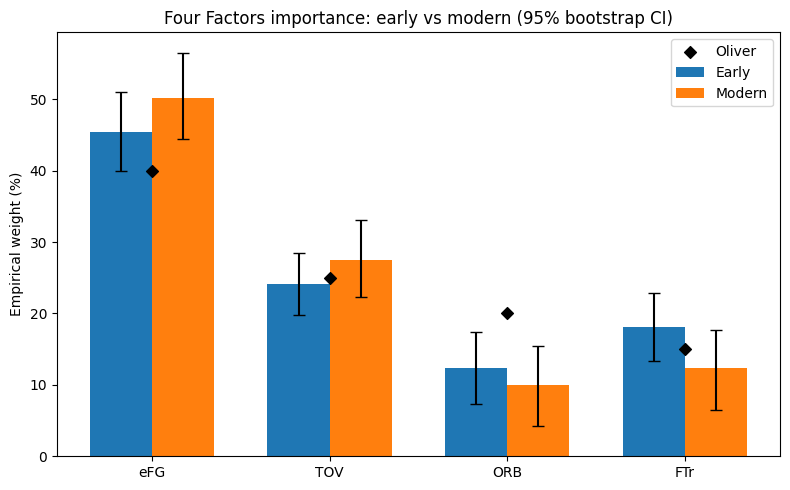

In [5]:
x = np.arange(len(FACTORS))
bar_w = 0.35

early_w = fit["early"]["weights"]
modern_w = fit["modern"]["weights"]
early_err = np.abs(weight_ci["early"] - early_w)
modern_err = np.abs(weight_ci["modern"] - modern_w)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - bar_w / 2, early_w, bar_w, yerr=early_err, capsize=4, label="Early")
ax.bar(x + bar_w / 2, modern_w, bar_w, yerr=modern_err, capsize=4, label="Modern")
ax.scatter(x, [OLIVER[f] for f in FACTORS], color="black", marker="D", zorder=5, label="Oliver")

ax.set_xticks(x)
ax.set_xticklabels(FACTORS)
ax.set_ylabel("Empirical weight (%)")
ax.set_title("Four Factors importance: early vs modern (95% bootstrap CI)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_coefficient_comparison.png", dpi=150)
plt.show()

## Robustness checks (secondary)

These are verification passes, not the headline result. Permutation importance on the per-era
logistic regression checks the coefficient ranking. Random Forest and XGBoost importance is
read via permutation importance only (impurity scores dilute under correlated features). The
full 12-feature logistic-regression coefficients are shown for transparency and are
correlation-affected, so they are context rather than a clean per-factor reading.


In [6]:
def perm_rank(model, X, y):
    model.fit(X, y)
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42,
                                    scoring="accuracy")
    return pd.Series(result.importances_mean, index=X.columns)


print("Permutation importance (mean accuracy drop) per era:")
for era in ERAS:
    sub = df[df["era"] == era]
    X, y = make_X(sub), sub["y"]
    ranking = pd.DataFrame({
        "logreg": perm_rank(logreg(), X, y),
        "rf": perm_rank(RandomForestClassifier(n_estimators=300, random_state=42), X, y),
        "xgb": perm_rank(XGBClassifier(n_estimators=300, random_state=42), X, y),
    })
    print(f"\n{era}:")
    print(ranking.round(4).to_string())

# Full 12-feature coefficients (correlation-affected; context only).
CORE12 = [f"{side}_{f}" for f in ["eFG", "TOV_pct", "ORB_pct", "FTrate"]
          for side in ["home", "away", "diff"]]
print("\n12-feature standardized logreg coefficients (correlation-affected, context only):")
for era in ERAS:
    sub = df[df["era"] == era]
    model = logreg().fit(sub[CORE12], sub["y"])
    print(f"\n{era}:")
    print(pd.Series(model.named_steps["clf"].coef_[0], index=CORE12).round(3).to_string())

Permutation importance (mean accuracy drop) per era:



early:
     logreg      rf     xgb
eFG  0.0562  0.3408  0.2631
TOV  0.0146  0.2507  0.2269
ORB  0.0049  0.1880  0.2197
FTr  0.0140  0.2426  0.2308



modern:
     logreg      rf     xgb
eFG  0.0676  0.3637  0.2727
TOV  0.0247  0.2773  0.2427
ORB  0.0039  0.1962  0.2366
FTr  0.0057  0.2026  0.2381

12-feature standardized logreg coefficients (correlation-affected, context only):

early:
home_eFG        0.192
away_eFG       -0.144
diff_eFG        0.241
home_TOV_pct   -0.113
away_TOV_pct    0.065
diff_TOV_pct   -0.132
home_ORB_pct    0.071
away_ORB_pct   -0.021
diff_ORB_pct    0.065
home_FTrate     0.097
away_FTrate    -0.038
diff_FTrate     0.098

modern:
home_eFG        0.184
away_eFG       -0.135
diff_eFG        0.233
home_TOV_pct   -0.053
away_TOV_pct    0.122
diff_TOV_pct   -0.130
home_ORB_pct    0.067
away_ORB_pct    0.005
diff_ORB_pct    0.046
home_FTrate     0.053
away_FTrate    -0.026
diff_FTrate     0.060
